# Test 16: Свёрточный Chaos SAE — сжатие CIFAR-10

**Идея:** Заменить Dense encoder/decoder на свёрточный, сохранив chaos activation + top-k в латентном слое.

**Архитектура:**
- Encoder: Conv2D → Conv2D → Flatten → Dense(latent) → chaos → top-k
- Decoder: Dense → Reshape → Conv2DTranspose → Conv2DTranspose → output

**Сравнение:**
- Conv + Chaos a=1 + TopK
- Conv + ReLU + TopK
- Dense + Chaos a=1 + TopK (из теста 15)

**Данные:** CIFAR-10, 20 эпох

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=64, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


print("Components ready.")

Components ready.


In [3]:
# === Архитектуры ===

LATENT_DIM = 256
TRAIN_K = 128

def build_conv_chaos_ae(image_shape=(32, 32, 3), latent_dim=256, k_active=128):
    """Свёрточный encoder + chaos activation в латенте + top-k"""
    input_img = keras.Input(shape=image_shape)
    
    # Encoder: свёртки
    x = layers.Conv2D(32, 3, strides=2, padding='same')(input_img)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.Activation(chaos_activation)(x)
    
    # Flatten → латент с chaos + top-k
    shape_before_flatten = x.shape[1:]
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')
    
    # Decoder: dense → reshape → деконволюции
    flat_dim = int(np.prod(shape_before_flatten))
    x = layers.Dense(flat_dim)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Reshape(shape_before_flatten)(x)
    
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same')(x)
    x = layers.Activation(chaos_activation)(x)
    decoded = layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')(x)
    
    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_conv_relu_ae(image_shape=(32, 32, 3), latent_dim=256, k_active=128):
    """Свёрточный encoder + ReLU + top-k"""
    input_img = keras.Input(shape=image_shape)
    
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(input_img)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    
    shape_before_flatten = x.shape[1:]
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')
    
    flat_dim = int(np.prod(shape_before_flatten))
    x = layers.Dense(flat_dim, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape(shape_before_flatten)(x)
    
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    decoded = layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')(x)
    
    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_dense_chaos_ae(image_shape=(32, 32, 3), latent_dim=256, k_active=128):
    """Dense encoder (из теста 15) для сравнения"""
    flat_dim = int(np.prod(image_shape))
    input_img = keras.Input(shape=image_shape)
    x = layers.Flatten()(input_img)
    x = layers.Dense(512)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(512)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(flat_dim, activation='sigmoid')(x)
    decoded = layers.Reshape(image_shape)(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("Architectures defined.")

Architectures defined.


In [4]:
# === Данные ===
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"CIFAR-10 train: {x_train.shape}, test: {x_test.shape}")

CIFAR-10 train: (50000, 32, 32, 3), test: (10000, 32, 32, 3)


In [5]:
# === Обучение и сравнение ===
EPOCHS = 20
BATCH_SIZE = 256
NUM_RUNS = 3

architectures = {
    'Conv+Chaos': lambda: build_conv_chaos_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K),
    'Conv+ReLU':  lambda: build_conv_relu_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K),
    'Dense+Chaos': lambda: build_dense_chaos_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K),
}

results = {}

for arch_name, builder in architectures.items():
    print(f"\n{'='*60}")
    print(f"  {arch_name}")
    print(f"{'='*60}")
    
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)
        
        ae, enc = builder()
        if run == 0:
            print(f"  Parameters: {ae.count_params():,}")
        
        history = ae.fit(
            x_train, x_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(x_test, x_test),
            verbose=0
        )
        
        latents = enc.predict(x_test, verbose=0)
        dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
        val_loss = history.history['val_loss'][-1]
        
        runs.append({
            'val_loss': float(val_loss),
            'dead_neurons': dead,
            'train_history': [float(l) for l in history.history['val_loss']],
        })
        
        print(f"  run {run+1}/{NUM_RUNS}: loss={val_loss:.4f}, dead={dead}/{LATENT_DIM}")
        
        del ae, enc
        keras.backend.clear_session()
    
    results[arch_name] = runs

print("\nTraining done.")


  Conv+Chaos


2026-04-06 18:14:26.216560: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 18:14:26.216582: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 18:14:26.216585: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 18:14:26.216600: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 18:14:26.216609: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


  Parameters: 1,245,443


2026-04-06 18:14:27.540845: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  run 1/3: loss=0.0408, dead=0/256
  run 2/3: loss=0.0062, dead=0/256
  run 3/3: loss=0.0127, dead=0/256

  Conv+ReLU
  Parameters: 1,245,443
  run 1/3: loss=0.0183, dead=18/256
  run 2/3: loss=0.0156, dead=11/256
  run 3/3: loss=0.0112, dead=12/256

  Dense+Chaos
  Parameters: 3,414,272
  run 1/3: loss=0.0139, dead=0/256
  run 2/3: loss=0.0130, dead=0/256
  run 3/3: loss=0.0133, dead=0/256

Training done.


In [6]:
# === Сводная таблица ===
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА")
print("=" * 60)
print(f"{'Архитектура':<15} {'Val Loss':>14} {'Dead':>12}")
print('-' * 45)

for arch_name in architectures:
    runs = results[arch_name]
    losses = [r['val_loss'] for r in runs]
    deads = [r['dead_neurons'] for r in runs]
    print(f"{arch_name:<15} {np.mean(losses):.4f} ± {np.std(losses):.4f} "
          f"{np.mean(deads):>5.1f} ± {np.std(deads):.1f}")


СВОДНАЯ ТАБЛИЦА
Архитектура           Val Loss         Dead
---------------------------------------------
Conv+Chaos      0.0199 ± 0.0150   0.0 ± 0.0
Conv+ReLU       0.0151 ± 0.0029  13.7 ± 3.1
Dense+Chaos     0.0134 ± 0.0004   0.0 ± 0.0


In [7]:
# === Rate-Distortion для лучшей модели ===
print("\nОбучение Conv+Chaos для rate-distortion...")
np.random.seed(0)
tf.random.set_seed(0)

ae_best, enc_best = build_conv_chaos_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K)
ae_best.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

all_latents = enc_best.predict(x_test, verbose=0)
print(f"Dead neurons: {np.sum(np.all(np.abs(all_latents) < 1e-6, axis=0))}/{LATENT_DIM}")

# Декодер
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = decoder_input
found_latent = False
for layer in ae_best.layers:
    if layer.name == 'latent_ksparse':
        found_latent = True
        continue
    if found_latent:
        x = layer(x)
decoder = keras.Model(decoder_input, x)


Обучение Conv+Chaos для rate-distortion...
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.0327
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0119
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0094
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0081
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0090
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0076
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0083
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0072
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0068
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0063
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0060
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0285
Epoch 13/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0378
Epoch 14/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0289

In [8]:
# === Функции сжатия ===

def apply_topk(latents, k):
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        top_idx = np.argsort(np.abs(latents[i]))[-k:]
        result[i, top_idx] = latents[i, top_idx]
    return result

def quantize(latents, bits):
    if bits >= 32:
        return latents
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            result[i, nz] = vals
            continue
        levels = 2 ** bits - 1
        norm = (vals - vmin) / (vmax - vmin)
        q = np.round(norm * levels) / levels
        result[i, nz] = q * (vmax - vmin) + vmin
    return result

def compression_ratio(latent_dim, k, bits):
    original = latent_dim * 32
    index_bits = int(np.ceil(np.log2(latent_dim)))
    compressed = k * bits + k * index_bits + 2 * 32
    return original / compressed

def psnr(orig, recon):
    mse = np.mean((orig - recon) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

print("Ready.")

Ready.


In [9]:
# === Rate-Distortion ===
print("Rate-Distortion для Conv+Chaos:")
rd_results = []

for k in [4, 8, 16, 32, 64, 128]:
    sparse = apply_topk(all_latents, k)
    for bits in [2, 4, 8, 32]:
        q = quantize(sparse, bits)
        recon = decoder.predict(q, verbose=0)
        recon = np.clip(recon, 0, 1)
        mse = float(np.mean((x_test - recon) ** 2))
        p = float(psnr(x_test, recon))
        cr = compression_ratio(LATENT_DIM, k, bits)
        rd_results.append({'k': k, 'bits': bits, 'mse': mse, 'psnr': p, 'cr': cr})
        print(f"  K={k:>3}, {bits:>2}bit: mse={mse:.4f}, psnr={p:.1f}dB, {cr:.1f}x")

Rate-Distortion для Conv+Chaos:
  K=  4,  2bit: mse=0.0627, psnr=12.0dB, 78.8x
  K=  4,  4bit: mse=0.0627, psnr=12.0dB, 73.1x
  K=  4,  8bit: mse=0.0627, psnr=12.0dB, 64.0x
  K=  4, 32bit: mse=0.0627, psnr=12.0dB, 36.6x
  K=  8,  2bit: mse=0.0606, psnr=12.2dB, 56.9x
  K=  8,  4bit: mse=0.0606, psnr=12.2dB, 51.2x
  K=  8,  8bit: mse=0.0606, psnr=12.2dB, 42.7x
  K=  8, 32bit: mse=0.0606, psnr=12.2dB, 21.3x
  K= 16,  2bit: mse=0.0586, psnr=12.3dB, 36.6x
  K= 16,  4bit: mse=0.0586, psnr=12.3dB, 32.0x
  K= 16,  8bit: mse=0.0586, psnr=12.3dB, 25.6x
  K= 16, 32bit: mse=0.0586, psnr=12.3dB, 11.6x
  K= 32,  2bit: mse=0.0585, psnr=12.3dB, 21.3x
  K= 32,  4bit: mse=0.0585, psnr=12.3dB, 18.3x
  K= 32,  8bit: mse=0.0585, psnr=12.3dB, 14.2x
  K= 32, 32bit: mse=0.0585, psnr=12.3dB, 6.1x
  K= 64,  2bit: mse=0.0623, psnr=12.1dB, 11.6x
  K= 64,  4bit: mse=0.0622, psnr=12.1dB, 9.8x
  K= 64,  8bit: mse=0.0622, psnr=12.1dB, 7.5x
  K= 64, 32bit: mse=0.0622, psnr=12.1dB, 3.1x
  K=128,  2bit: mse=0.0673, psnr

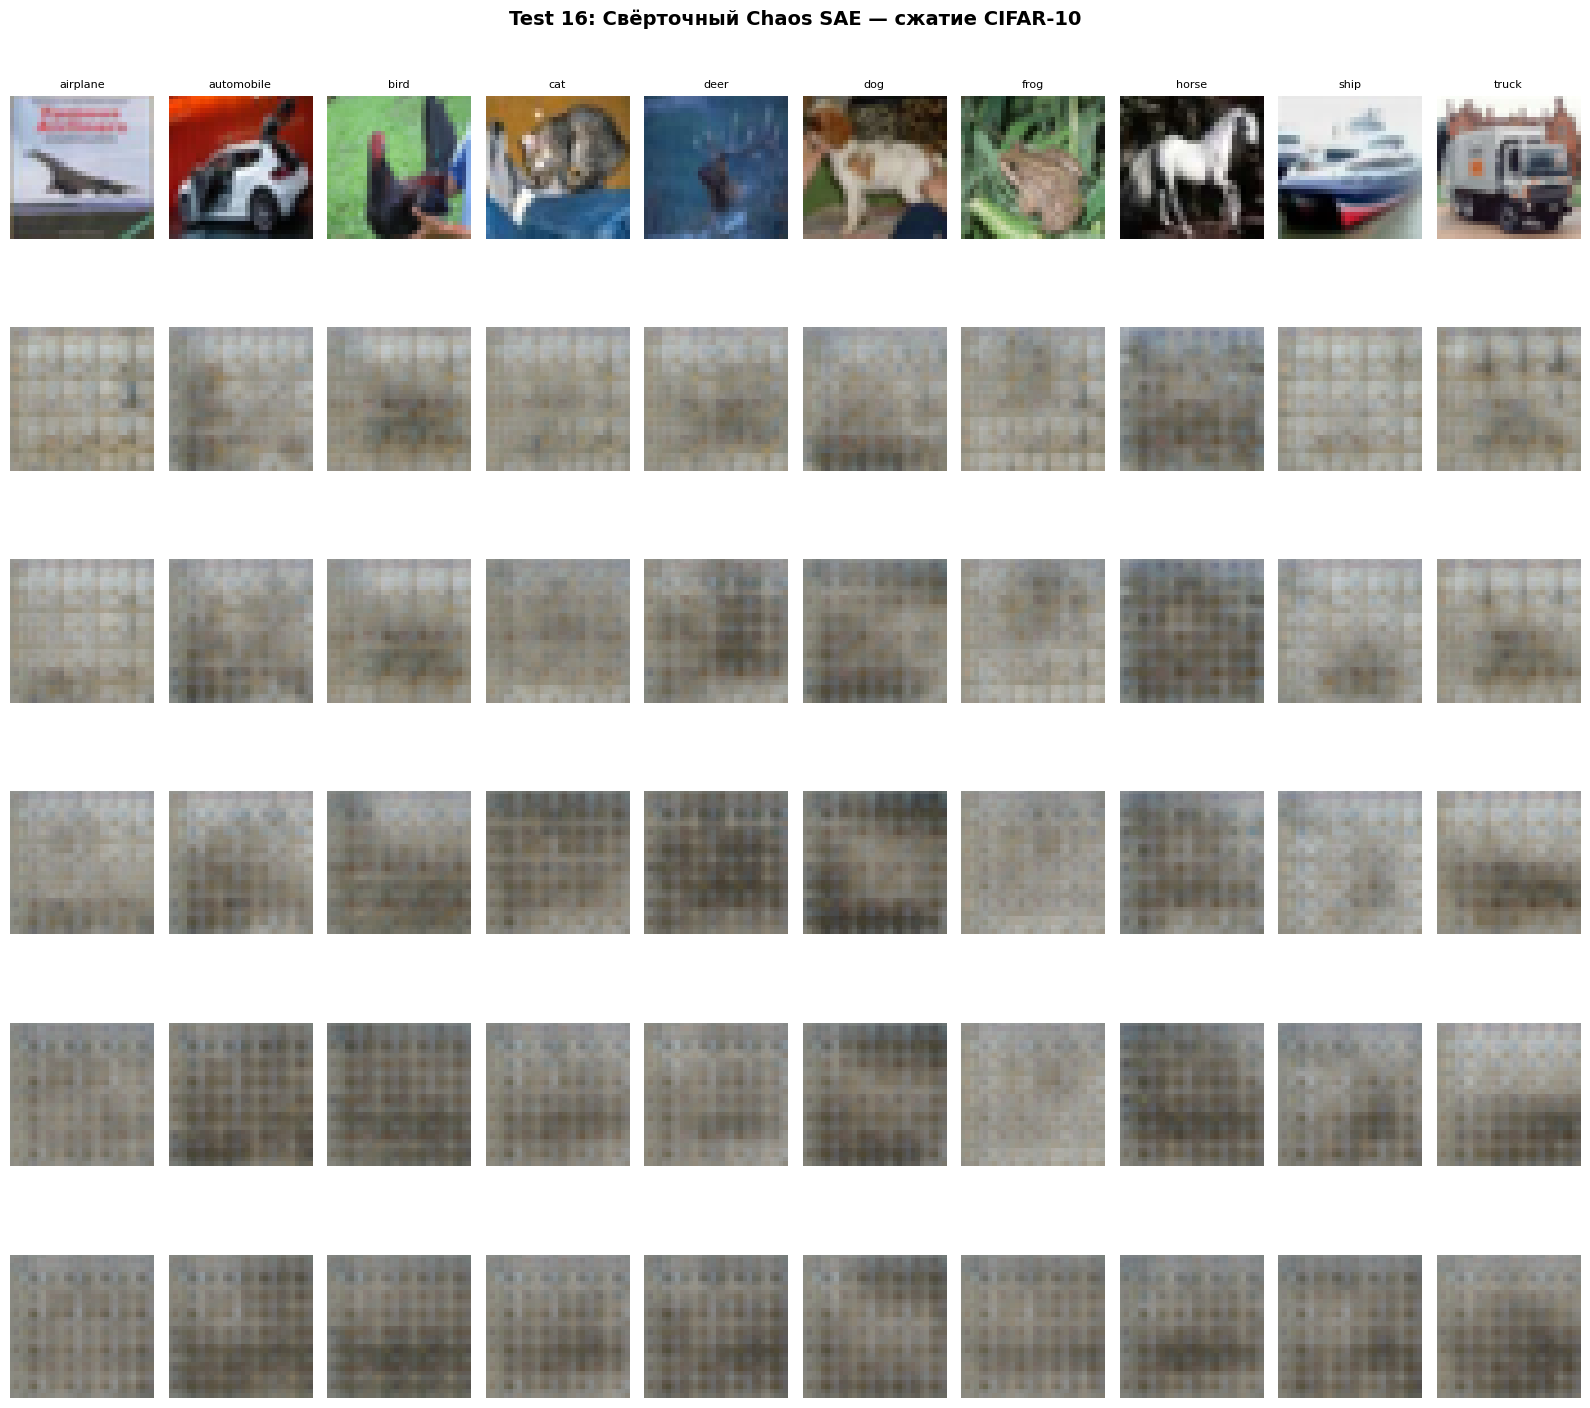

In [10]:
# === Визуализация: все 10 классов ===
demo_indices = [np.where(y_test.flatten() == c)[0][0] for c in range(10)]
demo_images = x_test[demo_indices]
demo_latents = all_latents[demo_indices]

settings = [
    ('Original', None, None),
    ('K=128, 8bit', 128, 8),
    ('K=64, 4bit', 64, 4),
    ('K=32, 4bit', 32, 4),
    ('K=16, 2bit', 16, 2),
    ('K=8, 2bit', 8, 2),
]

fig, axes = plt.subplots(len(settings), 10, figsize=(16, 2.5 * len(settings)))

for row, (label, k, bits) in enumerate(settings):
    for col in range(10):
        if k is None:
            axes[row, col].imshow(demo_images[col])
        else:
            lat = demo_latents[col:col+1]
            sparse = apply_topk(lat, k)
            q = quantize(sparse, bits)
            recon = decoder.predict(q, verbose=0)[0]
            recon = np.clip(recon, 0, 1)
            axes[row, col].imshow(recon)
        
        if row == 0:
            axes[row, col].set_title(class_names[col], fontsize=8)
        axes[row, col].axis('off')
    
    if k is not None:
        cr = compression_ratio(LATENT_DIM, k, bits)
        axes[row, 0].set_ylabel(f'{label}\n{cr:.0f}x', fontsize=8, rotation=0, labelpad=70)
    else:
        axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=70)

plt.suptitle('Test 16: Свёрточный Chaos SAE — сжатие CIFAR-10',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

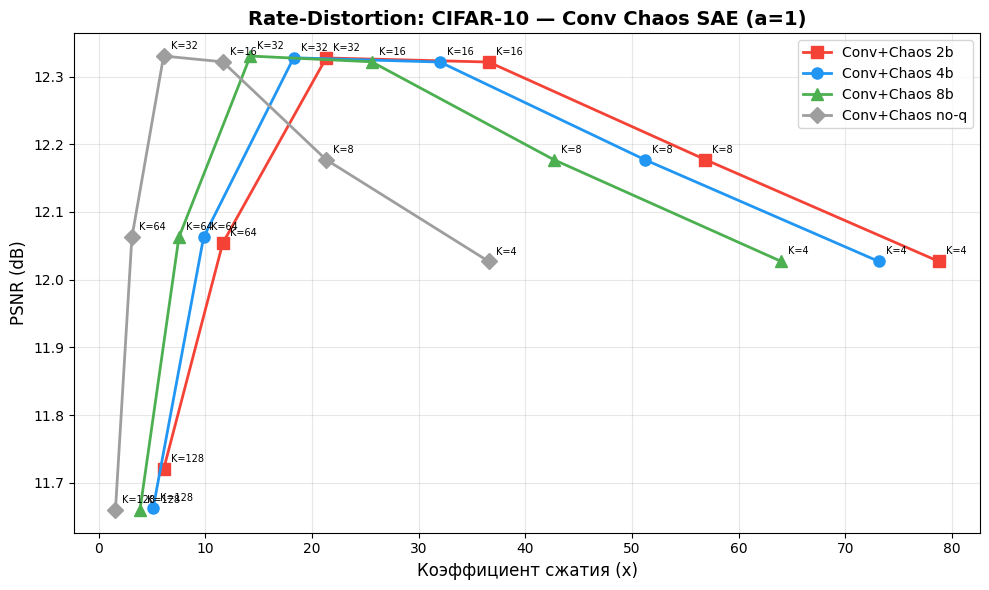

In [11]:
# === Rate-Distortion график: Conv vs Dense ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bit_colors = {2: '#F44336', 4: '#2196F3', 8: '#4CAF50', 32: '#9E9E9E'}
bit_markers = {2: 's', 4: 'o', 8: '^', 32: 'D'}

for bits in [2, 4, 8, 32]:
    pts = [r for r in rd_results if r['bits'] == bits]
    crs = [r['cr'] for r in pts]
    psnrs = [r['psnr'] for r in pts]
    label = f'Conv+Chaos {bits}b' if bits < 32 else 'Conv+Chaos no-q'
    ax.plot(crs, psnrs, color=bit_colors[bits], marker=bit_markers[bits],
            linewidth=2, markersize=8, label=label)
    for r in pts:
        ax.annotate(f'K={r["k"]}', (r['cr'], r['psnr']),
                   textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel('Коэффициент сжатия (x)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Rate-Distortion: CIFAR-10 — Conv Chaos SAE (a=1)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# === Сохранение ===
save_data = {
    'experiment': 'conv_compression',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'CIFAR-10',
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': LATENT_DIM,
        'train_k': TRAIN_K,
        'num_runs': NUM_RUNS,
    },
    'training_results': results,
    'rate_distortion': rd_results,
}

json_path = f'../jsons/conv_compression_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/conv_compression_20260406_183400.json
